# Task 1.1 — Preprocesamiento de ETTh1

In [1]:
import ssl
import urllib.request
import urllib.error
from pathlib import Path

import certifi
import numpy as np
import torch

torch.manual_seed(42)
print(f'PyTorch: {torch.__version__}')

PyTorch: 2.13.0


## 1. Descarga y carga de datos

In [2]:
URL = (
    'https://raw.githubusercontent.com/zhouhaoyi/'
    'ETDataset/main/ETT-small/ETTh1.csv'
)
DATA_PATH = Path('ETTh1.csv')

if not DATA_PATH.exists():
    try:
        urllib.request.urlretrieve(URL, DATA_PATH)
    except urllib.error.URLError as error:
        if DATA_PATH.exists():
            DATA_PATH.unlink()
        ssl_context = ssl.create_default_context(cafile=certifi.where())
        with urllib.request.urlopen(URL, context=ssl_context) as response:
            DATA_PATH.write_bytes(response.read())
        print(f'La descarga estándar falló ({error.reason}); se usó certifi.')
    print(f'Dataset descargado en {DATA_PATH.resolve()}')
else:
    print(f'Se reutiliza el dataset existente en {DATA_PATH.resolve()}')

data = np.genfromtxt(DATA_PATH, delimiter=',', skip_header=1)
OT = data[:, -1].astype(np.float32)
ALL = data[:, 1:].astype(np.float32)

assert OT.ndim == 1
assert ALL.ndim == 2 and ALL.shape[1] == 7
assert np.isfinite(OT).all() and np.isfinite(ALL).all()

print(f'Datos completos: {data.shape}')
print(f'OT: {OT.shape}')
print(f'ALL: {ALL.shape}')

Se reutiliza el dataset existente en /Users/nilsmurallesmorales/universidad/octavosemestre/deep/lab7/ETTh1.csv
Datos completos: (17420, 8)
OT: (17420,)
ALL: (17420, 7)


## 2. Normalización de `OT`

In [3]:
OT_tensor = torch.from_numpy(OT)

mu = OT_tensor.mean()
sigma = OT_tensor.std(correction=0)
assert sigma > 0, 'La desviación estándar debe ser positiva.'

OT_norm = (OT_tensor - mu) / sigma

print(f'mu    = {mu.item():.6f}')
print(f'sigma = {sigma.item():.6f}')
print(f'Media normalizada: {OT_norm.mean().item():.7f}')
print(f'Desv. normalizada: {OT_norm.std(correction=0).item():.7f}')

mu    = 13.324672
sigma = 8.566700
Media normalizada: -0.0000000
Desv. normalizada: 1.0000000


## 3. Split temporal contiguo 60/20/20

In [4]:
T = OT_norm.numel()
train_end = int(0.60 * T)
val_end = int(0.80 * T)

train_series = OT_norm[:train_end].clone()
val_series = OT_norm[train_end:val_end].clone()
test_series = OT_norm[val_end:].clone()

assert train_series.numel() + val_series.numel() + test_series.numel() == T
assert torch.equal(torch.cat((train_series, val_series, test_series)), OT_norm)

print(f'Total:         {T:5d} observaciones')
print(f'Entrenamiento: {train_series.numel():5d} ({train_series.numel()/T:.2%})')
print(f'Validación:    {val_series.numel():5d} ({val_series.numel()/T:.2%})')
print(f'Prueba:        {test_series.numel():5d} ({test_series.numel()/T:.2%})')
print(f'Índices: train=[0, {train_end}), val=[{train_end}, {val_end}), test=[{val_end}, {T})')

Total:         17420 observaciones
Entrenamiento: 10452 (60.00%)
Validación:     3484 (20.00%)
Prueba:         3484 (20.00%)
Índices: train=[0, 10452), val=[10452, 13936), test=[13936, 17420)


## 4. Construcción de ventanas

In [5]:
def make_windows(series: torch.Tensor, L: int, H: int) -> tuple[torch.Tensor, torch.Tensor]:
    if series.ndim != 1:
        raise ValueError(f'series debe ser 1D; forma recibida: {tuple(series.shape)}')
    if not isinstance(L, int) or not isinstance(H, int) or L <= 0 or H <= 0:
        raise ValueError('L y H deben ser enteros positivos.')
    if series.numel() < L + H:
        raise ValueError(
            f'Serie insuficiente: se requieren al menos L+H={L+H} valores, '
            f'pero hay {series.numel()}.'
        )

    windows = series.unfold(dimension=0, size=L + H, step=1)
    X = windows[:, :L].contiguous()
    y = windows[:, L + H - 1].contiguous()
    return X, y

### Prueba pequeña de indexación

In [6]:
toy = torch.arange(8, dtype=torch.float32)
X_toy, y_toy = make_windows(toy, L=3, H=2)

assert torch.equal(X_toy[0], torch.tensor([0.0, 1.0, 2.0]))
assert y_toy[0].item() == 4.0
assert X_toy.shape == (4, 3) and y_toy.shape == (4,)

print('X de prueba:\n', X_toy)
print('y de prueba:', y_toy)

X de prueba:
 tensor([[0., 1., 2.],
        [1., 2., 3.],
        [2., 3., 4.],
        [3., 4., 5.]])
y de prueba: tensor([4., 5., 6., 7.])


## 5. Ventanas para $L=96$ y $H\in\{24,48\}$

In [7]:
L = 96
HORIZONS = (24, 48)
series_by_split = {
    'train': train_series,
    'val': val_series,
    'test': test_series,
}

datasets = {}
for H in HORIZONS:
    datasets[H] = {}
    print(f'\nHorizonte H={H}')
    for split_name, split_series in series_by_split.items():
        X, y = make_windows(split_series, L=L, H=H)
        datasets[H][split_name] = (X, y)

        expected_n = split_series.numel() - L - H + 1
        assert X.shape == (expected_n, L)
        assert y.shape == (expected_n,)
        assert X.dtype == torch.float32 and y.dtype == torch.float32
        print(f'  {split_name:5s}: X={tuple(X.shape)}, y={tuple(y.shape)}')


Horizonte H=24
  train: X=(10333, 96), y=(10333,)
  val  : X=(3365, 96), y=(3365,)
  test : X=(3365, 96), y=(3365,)

Horizonte H=48
  train: X=(10309, 96), y=(10309,)
  val  : X=(3341, 96), y=(3341,)
  test : X=(3341, 96), y=(3341,)


## 6. Acceso y desnormalización

In [8]:
X_train_24, y_train_24 = datasets[24]['train']
X_val_24, y_val_24 = datasets[24]['val']
X_test_24, y_test_24 = datasets[24]['test']

X_train_48, y_train_48 = datasets[48]['train']
X_val_48, y_val_48 = datasets[48]['val']
X_test_48, y_test_48 = datasets[48]['test']

OT_train, OT_val, OT_test = train_series, val_series, test_series
X_tr_24, y_tr_24 = X_train_24, y_train_24
X_vl_24, y_vl_24 = X_val_24, y_val_24
X_ts_24, y_ts_24 = X_test_24, y_test_24
X_tr_48, y_tr_48 = X_train_48, y_train_48
X_vl_48, y_vl_48 = X_val_48, y_val_48
X_ts_48, y_ts_48 = X_test_48, y_test_48

y_train_24_celsius = y_train_24 * sigma + mu

first_target_index = L + 24 - 1
assert torch.allclose(y_train_24_celsius[0], OT_tensor[first_target_index])

print('Primer objetivo normalizado:', y_train_24[0].item())
print('Primer objetivo en °C:', y_train_24_celsius[0].item())

Primer objetivo normalizado: 2.0002248287200928
Primer objetivo en °C: 30.459999084472656


# Task 1.2 — Función de autocorrelación

## 1. Implementación de `acf_manual`

In [9]:
def acf_manual(series, max_lag):
    x = torch.as_tensor(series, dtype=torch.float32)
    if x.ndim != 1:
        raise ValueError(f'series debe ser 1D; forma recibida: {tuple(x.shape)}')
    if not isinstance(max_lag, int) or max_lag < 0:
        raise ValueError('max_lag debe ser un entero no negativo.')
    if max_lag >= x.numel():
        raise ValueError('max_lag debe ser menor que la longitud de la serie.')

    N = x.numel()
    centered = x - x.mean()
    denominator = centered.square().mean()
    if denominator == 0:
        raise ValueError('La ACF no está definida para una serie constante.')

    return torch.stack([
        (centered[k:] * centered[:N - k]).mean() / denominator
        for k in range(max_lag + 1)
    ])

## 2. Correlograma con intervalo de confianza del 95%

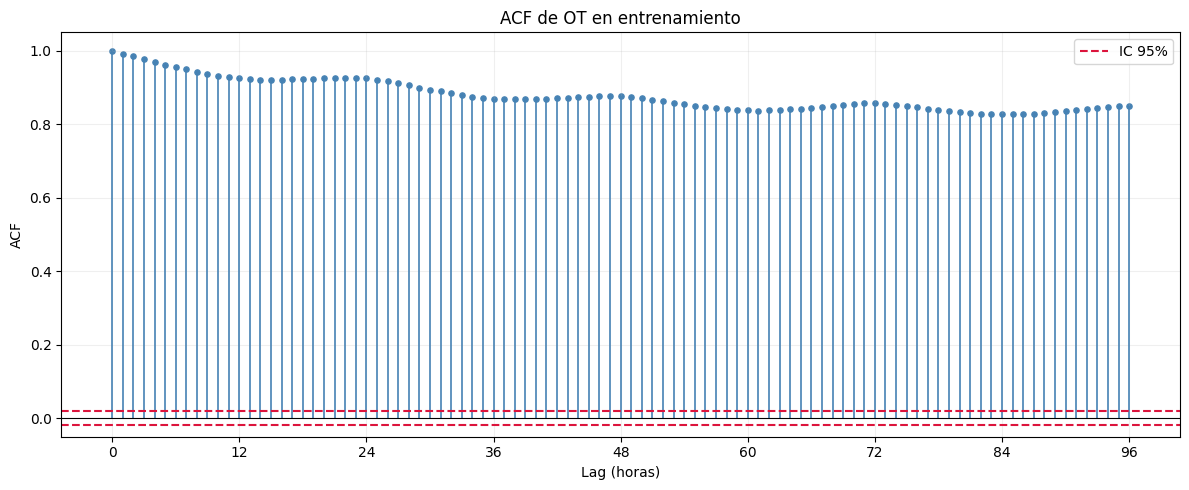

IC 95%: ±0.0192
ACF(24)=0.9250
ACF(48)=0.8763
ACF(72)=0.8572
ACF(96)=0.8489


In [10]:
import matplotlib.pyplot as plt

max_lag = 96
acf_values = acf_manual(OT_train, max_lag)
lags = torch.arange(max_lag + 1)
confidence = 1.96 / torch.sqrt(torch.tensor(OT_train.numel(), dtype=torch.float32))

plt.figure(figsize=(12, 5))
plt.vlines(lags.numpy(), 0, acf_values.numpy(), color='steelblue', linewidth=1.2)
plt.scatter(lags.numpy(), acf_values.numpy(), color='steelblue', s=14)
plt.axhline(confidence.item(), color='crimson', linestyle='--', label='IC 95%')
plt.axhline(-confidence.item(), color='crimson', linestyle='--')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Lag (horas)')
plt.ylabel('ACF')
plt.title('ACF de OT en entrenamiento')
plt.xticks(torch.arange(0, max_lag + 1, 12).numpy())
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

print(f'IC 95%: ±{confidence.item():.4f}')
print(f'ACF(24)={acf_values[24].item():.4f}')
print(f'ACF(48)={acf_values[48].item():.4f}')
print(f'ACF(72)={acf_values[72].item():.4f}')
print(f'ACF(96)={acf_values[96].item():.4f}')

## 3. Segundo pico e interpretación

In [11]:
local_peak_mask = (acf_values[1:-1] > acf_values[:-2]) & (acf_values[1:-1] > acf_values[2:])
local_peak_lags = torch.arange(1, max_lag)[local_peak_mask]
second_peak_lag = local_peak_lags[torch.argmax(acf_values[local_peak_lags])]
second_peak_acf = acf_values[second_peak_lag]

print(f'Segundo pico: lag {second_peak_lag.item()} con ACF={second_peak_acf.item():.4f}.')
print(
    f'El pico en {second_peak_lag.item()} horas y la ACF(24)={acf_values[24].item():.4f} '
    'muestran una periodicidad aproximadamente diaria en la temperatura del aceite.'
)

Segundo pico: lag 22 con ACF=0.9262.
El pico en 22 horas y la ACF(24)=0.9250 muestran una periodicidad aproximadamente diaria en la temperatura del aceite.


## 4. Justificación de $L=96$

In [12]:
print(
    f'L=96 es apropiado porque incluye cuatro ciclos diarios y cubre los picos alrededor de '
    f'22, 47 y 72 horas. La autocorrelación es alta en 24 horas ({acf_values[24].item():.4f}) '
    f'y todavía alcanza {acf_values[96].item():.4f} en 96 horas. Una ventana menor perdería '
    'parte de esa dependencia; una mayor podría capturar memoria adicional, pero aumentaría el costo del modelo.'
)

L=96 es apropiado porque incluye cuatro ciclos diarios y cubre los picos alrededor de 22, 47 y 72 horas. La autocorrelación es alta en 24 horas (0.9250) y todavía alcanza 0.8489 en 96 horas. Una ventana menor perdería parte de esa dependencia; una mayor podría capturar memoria adicional, pero aumentaría el costo del modelo.


## 5. Verificación de la Task 1

In [13]:
_ok = True

assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    'Los splits no cubren toda la serie'
assert OT_train[-1] != OT_val[0], \
    'El ultimo valor de train no debe ser el primero de val'

assert X_tr_24.shape[1] == 96, f'Ventana incorrecta: {X_tr_24.shape[1]}'
assert y_tr_24.shape[0] == X_tr_24.shape[0], 'X e y tienen distinto numero de ejemplos'

acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f'ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])'

naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f'Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])'

print(f'Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})')

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.1996)
